In [5]:
#Q1
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction
import pandas as pd
import numpy as np

data = {
    'sample': ['S01','S02','S03','S04','S05','S06','S07','S08'],
    'gene': ['BRCA1','TP53','INS','EGFR','MYC','PTEN','RB1','APC'],
    'gc_percent': [41.2,53.1,64.3,49.8,57.4,38.1,44.2,61.0],
    'length_bp': [7088,2591,465,5820,1624,3200,8500,2100],
    'patient': ['P001','P002','P003','P004','P005','P006','P007','P008']
}
df = pd.DataFrame(data)
df

,sample,gene,gc_percent,length_bp,patient
0,S01,BRCA1,41.2,7088,P001
1,S02,TP53,53.1,2591,P002
2,S03,INS,64.3,465,P003
3,S04,EGFR,49.8,5820,P004
4,S05,MYC,57.4,1624,P005
5,S06,PTEN,38.1,3200,P006
6,S07,RB1,44.2,8500,P007
7,S08,APC,61.0,2100,P008


In [8]:
flagged = df[(df["gc_percent"]<40) |  (df["length_bp"]>8000)]
df["quality_flag"] = np.where((df["gc_percent"]<40) |  (df["length_bp"]>8000),"FAIL","PASS")
df


,sample,gene,gc_percent,length_bp,patient,quality_flag
0,S01,BRCA1,41.2,7088,P001,PASS
1,S02,TP53,53.1,2591,P002,PASS
2,S03,INS,64.3,465,P003,PASS
3,S04,EGFR,49.8,5820,P004,PASS
4,S05,MYC,57.4,1624,P005,PASS
5,S06,PTEN,38.1,3200,P006,FAIL
6,S07,RB1,44.2,8500,P007,FAIL
7,S08,APC,61.0,2100,P008,PASS


In [9]:
print("Total Samples:", len(df))
print("Passed:", len(df[df["quality_flag"] == "PASS"]))
print("Failed:", len(df[df["quality_flag"] == "FAIL"]))
print("Failed Samples:", df[df["quality_flag"] == "FAIL"]["sample"].tolist())

Total Samples: 8
Passed: 6
Failed: 2
Failed Samples: ['S06', 'S07']


In [3]:
#q2
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction
import pandas as pd
import numpy as np

data1 = {
    'gene': ['BRCA1','BRCA1','TP53','TP53','INS','INS',
             'EGFR','EGFR','MYC','MYC','PTEN','PTEN'],
    
    'patient': ['Healthy','Cancer','Healthy','Cancer',
                'Healthy','Cancer','Healthy','Cancer',
                'Healthy','Cancer','Healthy','Cancer'],
    
    'expression': [2.1,8.7,
                   3.2,9.1,
                   5.5,5.8,
                   4.3,14.2,
                   3.9,11.2,
                   6.1,6.4]
}
df = pd.DataFrame(data1)
df

,gene,patient,expression
0,BRCA1,Healthy,2.1
1,BRCA1,Cancer,8.7
2,TP53,Healthy,3.2
3,TP53,Cancer,9.1
4,INS,Healthy,5.5
5,INS,Cancer,5.8
6,EGFR,Healthy,4.3
7,EGFR,Cancer,14.2
8,MYC,Healthy,3.9
9,MYC,Cancer,11.2


In [5]:
avg = df.groupby(["gene", "patient"], as_index=True).mean(numeric_only=True)

avg = avg.unstack()

avg["Fold Change"] = avg[("expression", "Cancer")] / avg[("expression", "Healthy")]

overexpressed = avg[avg["Fold Change"] > 2]

print("\nOverexpressed Genes\n")

for gene, row in overexpressed.iterrows():
    print(f"Gene         : {gene}")
    print(f"Cancer Avg   : {row[('expression','Cancer')]:.2f}")
    print(f"Healthy Avg  : {row[('expression','Healthy')]:.2f}")
    print(f"Fold Change  : {row['Fold Change']}")
    print("-"*30)


Overexpressed Genes

Gene         : BRCA1
Cancer Avg   : 8.70
Healthy Avg  : 2.10
Fold Change  : patient
    4.142857
Name: BRCA1, dtype: float64
------------------------------
Gene         : EGFR
Cancer Avg   : 14.20
Healthy Avg  : 4.30
Fold Change  : patient
    3.302326
Name: EGFR, dtype: float64
------------------------------
Gene         : MYC
Cancer Avg   : 11.20
Healthy Avg  : 3.90
Fold Change  : patient
    2.871795
Name: MYC, dtype: float64
------------------------------
Gene         : TP53
Cancer Avg   : 9.10
Healthy Avg  : 3.20
Fold Change  : patient
    2.84375
Name: TP53, dtype: float64
------------------------------


In [7]:
#q3
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction
import pandas as pd
import numpy as np

import pandas as pd

data2 = {
    'patient_id': ['P01','P02','P03','P04','P05',
                   'P06','P07','P08','P09','P10',
                   'P01','P02','P03','P04','P05',
                   'P06','P07','P08','P09','P10'],

    'gene': ['BRCA1']*10 + ['TP53']*10,

    'mutated': [
        True, True, False, True, True,
        False, True, True, False, True,

        True, False, True, True, True,
        True, False, True, True, True
    ]
}

df = pd.DataFrame(data2)
df


,patient_id,gene,mutated
0,P01,BRCA1,True
1,P02,BRCA1,True
2,P03,BRCA1,False
3,P04,BRCA1,True
4,P05,BRCA1,True
5,P06,BRCA1,False
6,P07,BRCA1,True
7,P08,BRCA1,True
8,P09,BRCA1,False
9,P10,BRCA1,True


In [9]:
#gene division
group = df.groupby("gene")
#total patients
total_patients = group["patient_id"].count()
#mutated patient
mutated_patients = group["mutated"].sum()
# Mutation rate
mutation_rate = (mutated_patients / total_patients) * 100

result = pd.DataFrame({
    "Total Patients": total_patients,
    "Mutated Patients": mutated_patients,
    "Mutation Rate": mutation_rate
})

# Hotspot
result["Hotspot"] = result["Mutation Rate"] > 60
# Highest Mutation rate
result = result.sort_values(by="Mutation Rate", ascending=False)
result = result.reset_index()
print(result)

    gene  Total Patients  Mutated Patients  Mutation Rate  Hotspot
0   TP53              10                 8           80.0     True
1  BRCA1              10                 7           70.0     True


In [10]:
#q4
from Bio import SeqIO
import pandas as pd
import numpy as np

sequences = {
    "EcoliGene1": "ATGGCTAAGCGTATCGATCGGCGCGCTATCGAATTTCCC",
    "EcoliGene2": "ATGCCCGGAAATTTGCGCGATCGATCGGCGCGGCGCGC",
    "EcoliGene3": "ATGATGATGATGATCGATCGATCGATCGATCGAAA",
    "SalGene1": "GCGCGCGCATCGATCGATCGATCGATCGGCGCGCGCGCGC",
    "SalGene2": "AAATTTAAATTTAAATTTAAATTTAAATTTAAATTTAAA",
    "SalGene3": "ATGGATCGGCGCGCGCATCGATCGATCGATCGCGCGATCGC"
}
sequences


{'EcoliGene1': 'ATGGCTAAGCGTATCGATCGGCGCGCTATCGAATTTCCC',
 'EcoliGene2': 'ATGCCCGGAAATTTGCGCGATCGATCGGCGCGGCGCGC',
 'EcoliGene3': 'ATGATGATGATGATCGATCGATCGATCGATCGAAA',
 'SalGene1': 'GCGCGCGCATCGATCGATCGATCGATCGGCGCGCGCGCGC',
 'SalGene2': 'AAATTTAAATTTAAATTTAAATTTAAATTTAAATTTAAA',
 'SalGene3': 'ATGGATCGGCGCGCGCATCGATCGATCGATCGCGCGATCGC'}

In [12]:
with open("genes.fasta", "w") as file:
    for gene, seq in sequences.items():
        file.write(f">{gene}\n")
        file.write(seq + "\n")
records = SeqIO.parse("genes.fasta", "fasta")
result = []

for record in records:

    gene = record.id
    seq = str(record.seq)

    length = len(seq)

    gc_count = seq.count("G") + seq.count("C")
    at_count = seq.count("A") + seq.count("T")

    gc_percent = (gc_count / length) * 100
    at_percent = (at_count / length) * 100

    if gc_count == 0:
        ratio = 0
    else:
        ratio = round(at_count / gc_count, 2)

    gc_type = "GC-rich" if gc_percent > 55 else "Normal"

    result.append([
        gene,
        length,
        round(gc_percent, 2),
        round(at_percent, 2),
        ratio,
        gc_type
    ])

df = pd.DataFrame(
    result,
    columns=[
        "Gene",
        "Length",
        "GC%",
        "AT%",
        "AT/GC Ratio",
        "GC Type"
    ]
)

df = df.sort_values(by="GC%", ascending=False).reset_index(drop=True)
print("\nMean GC% =", round(df["GC%"].mean(), 2))
df


Mean GC% = 50.52


,Gene,Length,GC%,AT%,AT/GC Ratio,GC Type
0,SalGene1,40,75.00,25.00,0.33,GC-rich
1,EcoliGene2,38,68.42,31.58,0.46,GC-rich
2,SalGene3,41,65.85,34.15,0.52,GC-rich
3,EcoliGene1,39,53.85,46.15,0.86,Normal
4,EcoliGene3,35,40.00,60.00,1.50,Normal
5,SalGene2,39,0.00,100.00,0.00,Normal


In [13]:
#q5
from Bio import Entrez, SeqIO
import pandas as pd
import matplotlib.pyplot as plt

Entrez.email = "rajatkandpal2006@gmail.com"

gene_ids = {
    "BRCA1": "NM_007294",
    "TP53": "NM_000546",
    "INS": "NM_000207"
}

results = []

In [14]:
for gene, accession in gene_ids.items():

    handle = Entrez.efetch(
        db="nucleotide",
        id=accession,
        rettype="gb",
        retmode="text"
    )

    record = SeqIO.read(handle, "genbank")

    seq = str(record.seq)

    length = len(seq)

    gc = seq.count("G") + seq.count("C")
    gc_percent = (gc / length) * 100

    protein = str(record.seq.translate())[:30]

    results.append([
        accession,
        record.description,
        length,
        round(gc_percent,2),
        protein
    ])

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\Bio\Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [15]:
df = pd.DataFrame(
    results,
    columns=[
        "ID",
        "Description",
        "Length",
        "GC%",
        "Protein"
    ],
    index=gene_ids.keys()
)
df

,ID,Description,Length,GC%,Protein
BRCA1,NM_007294,Homo sapiens BRCA1 DNA repair associated (BRCA...,7088,41.77,AETSWTGDRLWGFSDNWAPALRRPSPSALG
TP53,NM_000546,"Homo sapiens tumor protein p53 (TP53), transcr...",2512,53.38,LKSLEPPSREQVAAGLRGHFAFGLGACFPR
INS,NM_000207,"Homo sapiens insulin (INS), transcript variant...",465,63.87,SPPGQAASEEAIKQITVLLPWPCGCASCPC


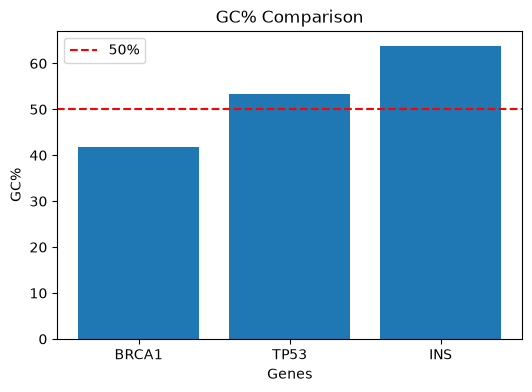


Highest GC Gene : INS
Longest Gene : BRCA1


In [17]:
plt.figure(figsize=(6,4))

plt.bar(df.index, df["GC%"])

plt.axhline(
    50,
    color="red",
    linestyle="--",
    label="50%"
)

plt.title("GC% Comparison")
plt.xlabel("Genes")
plt.ylabel("GC%")
plt.legend()

plt.show()

with open("cancer_genes_report.txt","w") as file:

    file.write(df.to_string())

    file.write("\n\n")

    file.write(
        "Highest GC : "
        + df["GC%"].idxmax()
        + "\n"
    )

    file.write(
        "Longest Gene : "
        + df["Length"].idxmax()
    )



print("\nHighest GC Gene :", df["GC%"].idxmax())
print("Longest Gene :", df["Length"].idxmax())